# Week 3: Backpropagation

Last week, we introduced Pytorch's [.backward()](https://pytorch.org/docs/stable/generated/torch.Tensor.backward.html) method, which we use for computing **gradients**.

When we do math with PyTorch tensors that have ```requires_grad=True```, PyTorch builds a graph tracking every operation this tensor undergoes during whats called the **forward pass**, which is the process of computing, piece by piece, the output of a function given its inputs. This process is done according to the rules of automatic differentiation we learned last week!

Let's look at a messy math problem with matrices, and ask what kinds of things Pytorch might be recording to make the backpropagation process possible.

$$L(w) = (2w + 1)^2$$

Run the forward pass from $w = 3$:
- $w = 3$
- $2w = 6$
- $2w + 1 = 7$
- $(2w + 1)^2 = 49$

So $L(3) = 49$.

In [1]:
import torch

# a miniature model-to-loss:  w -> *2 -> +1 -> square
w = torch.tensor(3.0, requires_grad=True)

step1 = w * 2       # 2 * 3 = 6
step2 = step1 + 1   # 6 + 1 = 7
step3 = step2 ** 2  # 7 * 7 = 49

print("the forward pass:", step1.item(), step2.item(), step3.item())

the forward pass: 6.0 7.0 49.0




$$\frac{dL}{dw} = \frac{d}{dw} (2w + 1)^2 = 2(2w + 1) \cdot 2 = 4(2w + 1) = 8w + 4$$

At $w = 3$, the derivative is:

$$\frac{dL}{dw}\bigg|_{w=3} = 8(3) + 4 = 24 + 4 = 28$$

So the slope of $L(w)$ at $w = 3$ is $28$.

Recall that we want the slope of the loss with respect to $w$: $dL/dw$.

Rather than differentiate the whole expression by hand, notice that each operation has a built-in rule for its own slope, and the rule needs the value the operation saw during the forward pass:

- the multiplication: the slope with respect to either operand is the other operand. The operands here are $w$ and 2, so the slope of step1 with respect to $w$ is 2.
- the addition: slope 1. Adding shifts values but does not scale them, so whatever slope flows in flows out unchanged.
- the square: slope $2 \times$ (the value it saw). It saw 7, so its slope is $2 \times 7 = 14$.

That third rule is of interest: the square's slope needs a value that only existed during the forward pass, which is why Pytorch records each operation together with the value that flowed through it, not just the list of operations.

This is the machinery that will scale: the gradient of a complex function is built by chaining the rules of its simple pieces, each rule evaluated at the value its piece saw. For our miniature, the chain through $w$ is

$$2 \times 1 \times 14 = 28$$

so $dL/dw = 28$ at $w = 3$, no whole-expression derivative needed. Now run the backward pass and let Pytorch do the chaining:

In [2]:
# the three rules, each evaluated at the value its operation saw:
slope_at_multiply = 2.0                # the other operand: 2
slope_at_add      = 1.0                # slopes pass through addition unchanged
slope_at_square   = 2 * step2.item()   # 2 * (the 7 it saw) = 14

print("the three rules:              ", slope_at_multiply, slope_at_add, slope_at_square)
print("chained together:             ", slope_at_multiply * slope_at_add * slope_at_square)

# the backward pass does the same chaining in one call:
step3.backward()
print("torch's dL/dw:                ", w.grad.item())

the three rules:               2.0 1.0 14.0
chained together:              28.0
torch's dL/dw:                 28.0


These rules, taken together, form the basis of the backpropagation algorithm. Now, back to gradients:

Gradients are **vectors of partial derivatives** that indicate the direction and rate of the steepest increase of a function, i.e., we can conceive of them as many rates like the above, in a list [dL/dw1, dL/dw2, ..., dL/dwn] where n is the number of parameters in the function.

# A first neural network

Now let's put gradients to work. We will build a model with thousands of parameters and train it the way the toy was trained: forward pass, backward pass, repeat. The model is our first tiny 'neural network'.

(**A frame from this week's reading.**) We have been saying "the model" all along, a bit loosely. Domingos gives names to the three things every learning system needs:

- a **representation**: the form the model takes,
- an **evaluation function**: how good a candidate model is (for us, the loss),
- an **optimization**: how we search for a better candidate (for us, gradient descent).

The network below is a new representation, a new form for the model. The evaluation and the search stay the same as before.



Neural networks is a bit of a misnomer, as the term "neural" is used to describe the way the network processes information, rather than the way it is structured. In a neural network, we have information flowing through a series of interconnected nodes, or "neurons". Each neuron receives input, processes it, and passes it on to the next layer of neurons.

The typical structure of a neural network consists of an input layer, one or more hidden layers, and an output layer. Each layer is made up of neurons that are connected to the neurons in the next layer.

![the layers of a neural network: every neuron connects to every neuron of the next layer](https://upload.wikimedia.org/wikipedia/commons/4/46/Colored_neural_network.svg)

The classic picture of a feedforward network: an input layer, one hidden layer, and an output layer, with every neuron sending its result to every neuron of the next layer. This notebook's network is the same picture with 784 input neurons, 16 hidden neurons, and one output neuron. In the code the columns stay implicit: the arrows between the input and hidden columns are the matrix $W_1$, and the arrows between the hidden and output columns are $W_2$.

*Figure: "Colored neural network" (Wikimedia Commons, CC BY-SA 3.0), the standard diagram of the Wikipedia article on artificial neural networks.*



**The problem.** The model looks at a picture of a handwritten digit and decides whether it is a 3 or a 7. Each picture arrives as a 28 by 28 grid of pixels, which we treat as a row of 784 numbers. The network:

- takes the 784 pixel values as its input,
- sends them through a hidden layer of 16 units,
- returns a single score: how 3-like the image is.

A score above 0.5 means "this is a 3", below 0.5 means "this is a 7". We train on 12,396 labeled example images, with the squared error we have been using all along: the target $t$ is 1 for a 3 and 0 for a 7.

**A layer of units.** Each of the 16 hidden units is a small neuron: it adds up its 784 weighted inputs plus a bias, then converts the sum into a firing rate between 0 and 1 with the sigmoid function. The output is one more weighted sum of the 16 firing rates plus a bias, left at its natural scale rather than squashed.



The parameters to tune:

- $W_1$, shape (784, 16): the weight from every pixel to every hidden unit
- $b_1$, shape (16,): one bias per hidden unit
- $W_2$, shape (16, 1): the weight from every hidden unit to the output
- $b_2$, shape (1,): the output bias

That is $784 \times 16 + 16 + 16 + 1 = 12{,}577$ parameters, so here $n = 12{,}577$ and the gradient from the last cell is a list of 12,577 slopes. The forward pass computes the score in three lines:

```
h_pre = X @ W1 + b1     # 12,396 pixels-rows @ (784, 16) weights -> 12,396 x 16 sums
h     = sigmoid(h_pre)  # firing rates, every entry squeezed into (0, 1)
y_hat = h @ W2 + b2     # 12,396 x 16 rates @ (16, 1) weights -> 12,396 scores
```

and the loss is the usual mean of $(\hat{y} - t)^2$ over the 12,396 training images.

training: (12396, 784) with 6131 threes and 6265 sevens
test:     (2038, 784) with 1010 threes and 1028 sevens


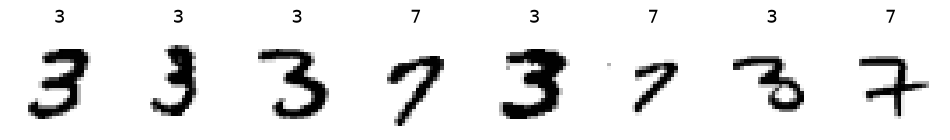

In [3]:
# the data: handwritten 3s and 7s from MNIST, a standard dataset.
# (torchvision fetches it for us; it downloads once, then reads from disk.)
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

train_data = datasets.MNIST(root="mnist_data", train=True, download=True)
test_data  = datasets.MNIST(root="mnist_data", train=False, download=True)

def select(data):
    pixels = data.data.numpy()              # every image as a 28 x 28 grid, 0..255
    labels = data.targets.numpy()
    keep = (labels == 3) | (labels == 7)    # only 3s and 7s
    X = torch.tensor(pixels[keep].reshape(-1, 784).astype("float32") / 255.0)
    t = torch.tensor((labels[keep] == 3).astype("float32")).reshape(-1, 1)
    return X, t

Xtr, ttr = select(train_data)               # X: pixel values, t: 1 for a 3, 0 for a 7
Xte, tte = select(test_data)                # held out: the model never trains on these

print("training:", tuple(Xtr.shape), "with", int(ttr.sum()), "threes and", int((1 - ttr).sum()), "sevens")
print("test:    ", tuple(Xte.shape), "with", int(tte.sum()), "threes and", int((1 - tte).sum()), "sevens")

# a look at the raw material: 8 training images with their labels
fig, axs = plt.subplots(1, 8, figsize=(12, 1.9))
for i, ax in enumerate(axs):
    ax.imshow(Xtr[i].reshape(28, 28), cmap="gray_r")
    ax.set_title("3" if ttr[i].item() else "7", fontsize=13)
    ax.axis("off")
plt.show()

In [4]:
# the 12,577 parameters, started at small random values.
# a pixel weight is small because 784 of them add up inside each unit.
# (the seed makes the random start identical on every run of this notebook)

torch.manual_seed(0)

W1 = torch.randn(784, 16) / np.sqrt(784)    # pixel -> hidden weights
b1 = torch.zeros(16)                        # hidden biases
W2 = torch.randn(16, 1) * 0.5               # hidden -> output weights
b2 = torch.zeros(1)                         # output bias

for p in (W1, b1, W2, b2):
    p.requires_grad_(True)                  # record the path from each to the loss

W1_start = W1.detach().clone()              # a copy of the random start, for later

print("W1", tuple(W1.shape), " b1", tuple(b1.shape),
      " W2", tuple(W2.shape), " b2", tuple(b2.shape))

W1 (784, 16)  b1 (16,)  W2 (16, 1)  b2 (1,)


**Run the forward pass.** In the toy, Pytorch recorded each operation together with the value that flowed through it, because each operation's built-in slope rule needs that value. The same happens here, at scale. The record fills with:

- the operations: matmul, add, sigmoid, square, mean,
- and every value that flowed through them: the 12,396 x 16 sums $h_{pre}$, the firing rates $h$, the 12,396 scores, and so on.

The forward pass here only evaluates and records: no slopes come out of it. `loss.backward()`, a few cells down, is what computes the slopes, by walking the record backward. (Not every tool works that way: a style called forward-mode computes slopes as values flow forward, operation by operation. Pytorch's `backward()` is the backward style, and that backward walk, chaining one rule after another over recorded values, is backpropagation.)

In [ ]:
# the forward pass, one layer at a time
h_pre = Xtr @ W1 + b1          # weighted sums
h     = torch.sigmoid(h_pre)   # firing rates in (0, 1)
y_hat = h @ W2 + b2            # the 12,396 scores

loss = ((y_hat - ttr) ** 2).mean()   # mse, our loss function

print("h_pre", tuple(h_pre.shape), " h", tuple(h.shape),
      " y_hat", tuple(y_hat.shape), " loss {:.4f}".format(loss.item()))


**What is a walk?** The record is a list of operations in the order they ran: matmul, add, sigmoid, and so on, each with the values that flowed through it. `backward()` goes through that list in reverse, from the loss back to the input, and at every operation it multiplies two things:

- the operation's slope rule, evaluated at the value the operation saw during the forward pass. These are the toy's rules again: a multiplication's slope with respect to either operand is the other operand, an addition's slope is 1, a square's slope is twice its input,
- by the product accumulated so far, from the operations closer to the loss.

Start with 1 at the loss. Walk one operation back: the accumulated product becomes the rule times the product. Walk again: multiply again. When the walk reaches a parameter, the number sitting there is that parameter's slope: $dL/dW_1[3, 7]$ for the weight from pixel 3 to hidden unit 7, and likewise for every entry of every parameter.

The walk reaches all of them at once: it branches at each operation the way the forward values did, and it leaves one tensor on every parameter, `p.grad`, shaped exactly like `p`. So: 12,577 parameters, 12,577 slopes, from one walk over the record. Nothing needed a formula for the whole network: only each operation's small rule, evaluated at a recorded value.

Run the cell below. `loss.backward()` does the walk just described, and the printed shapes show where it left the slopes.

In [ ]:
loss.backward()    # the backward pass: one chained rule per recorded operation

print("W1.grad", tuple(W1.grad.shape), " b1.grad", tuple(b1.grad.shape))
print("W2.grad", tuple(W2.grad.shape), " b2.grad", tuple(b2.grad.shape))

# clear the demo gradients: torch adds each backward pass onto whatever .grad
# already holds, and the training loop below must start from zero
for p in (W1, b1, W2, b2):
    p.grad = None


**The walk, in the classic picture.** The two figures below come from Christopher Olah's blog post "Calculus on Computational Graphs: Backpropagation" (2015), the standard written introduction to this material:

![the forward pass over a small graph](https://colah.github.io/posts/2015-08-Backprop/img/chain-forward.png) ![the same graph walked backward](https://colah.github.io/posts/2015-08-Backprop/img/chain-reverse.png)

Left: values move forward through a small graph, each node combining its inputs and passing the result on. Right: the same graph, walked backward, with slopes moving in from the output side. At each node the slope arriving from the output side is multiplied by that node's rule, and the result continues on toward the inputs. The number an input finally receives is the slope of the whole function with respect to that input. That is the walk described above, drawn instead of described: every operation's rule evaluated at a recorded forward value, chained back to the parameters. `loss.backward()` just did it for this notebook's network.

**Gradient descent, the actual learning step.** Each entry of `p.grad` is the slope of the loss at that weight: it points the way the loss rises. To lower the loss we move each weight a small step the other way:

$$p \leftarrow p - lr \cdot p.grad \quad \text{for every parameter } p, \text{ entry by entry}$$

The step size `lr` (the learning rate) is a small number we choose; here 0.1. One training step is: forward pass, backward pass, update all 12,577 parameters. Then repeat. After an update the old record is out of date, so each repetition recomputes it with a fresh forward pass.

The loop below runs that training step 200 times, and reports every 50 steps: the loss, and how often the score points the right way (above 0.5 for a 3, below for a 7), both on the training images and on the held-out test images. This is the third piece of the frame from the opening, in action: gradient descent, the search over the network's parameters.

In [7]:
# 200 training steps: forward, backward, update. One pass of the whole
# training set per step (a "full batch").
lr = 0.1
losses, train_accs, test_accs, step_marks = [], [], [], []

for step in range(201):
    # --- forward pass ---
    h_pre = Xtr @ W1 + b1
    h = torch.sigmoid(h_pre)
    y_hat = h @ W2 + b2
    loss = ((y_hat - ttr) ** 2).mean()

    # --- backward pass ---
    loss.backward()

    if step % 50 == 0:
        with torch.no_grad():
            train_acc = ((torch.sigmoid(Xtr @ W1 + b1) @ W2 + b2 > 0.5).float() == ttr).float().mean()
            test_acc  = ((torch.sigmoid(Xte @ W1 + b1) @ W2 + b2 > 0.5).float() == tte).float().mean()
        losses.append(loss.item())
        train_accs.append(train_acc.item())
        test_accs.append(test_acc.item())
        step_marks.append(step)
        print(f"step {step:4d}   loss {loss.item():.4f}   train accuracy {train_acc.item():.3f}   test accuracy {test_acc.item():.3f}")

    if step == 200:
        break                      # the state just reported is the final one

    # --- update every parameter a small step against its gradient ---
    with torch.no_grad():
        for p in (W1, b1, W2, b2):
            p -= lr * p.grad
            p.grad = None          # clear, so the next backward starts from zero

step    0   loss 0.4880   train accuracy 0.495   test accuracy 0.496


step   50   loss 0.0355   train accuracy 0.978   test accuracy 0.971


step  100   loss 0.0295   train accuracy 0.982   test accuracy 0.977


step  150   loss 0.0266   train accuracy 0.983   test accuracy 0.979


step  200   loss 0.0247   train accuracy 0.984   test accuracy 0.980


**What the run says.** The loss starts near 0.49, which is what a random score guesses: on a set that is half 3s and half 7s, always guessing 0.5 gets about half wrong. Two hundred steps later the loss is around 0.025, and the accuracy on both the training images and the held-out test images is just under 0.98. Test accuracy about the same as training accuracy is the sign that matters: the network learned the general 3-versus-7 distinction, not a memorized list of training pictures.

The figures below show the run and then let you look inside the trained network.

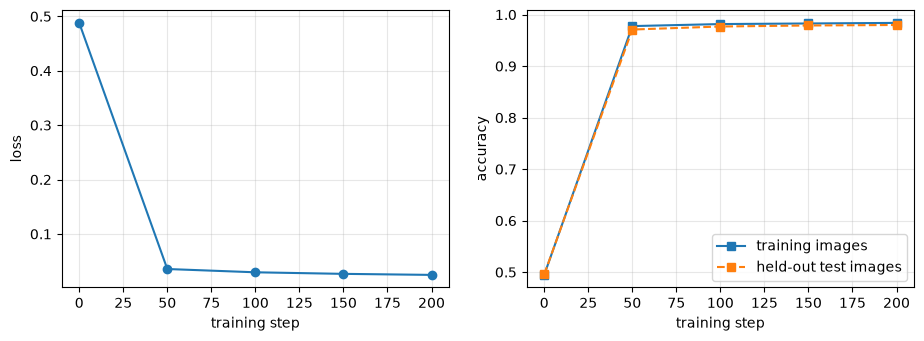

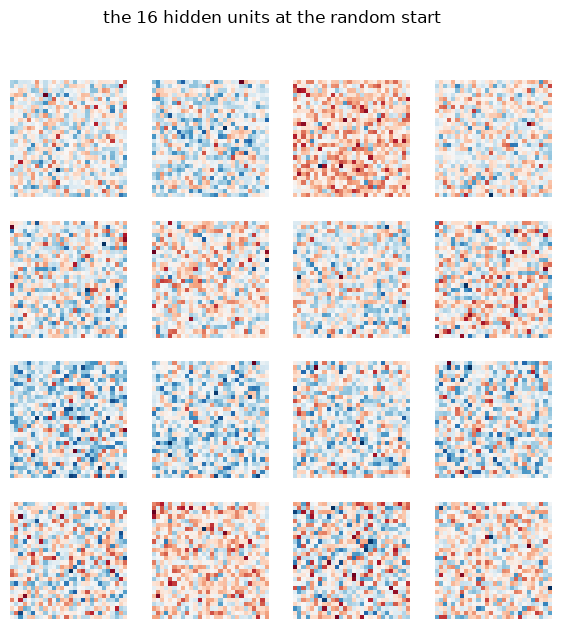

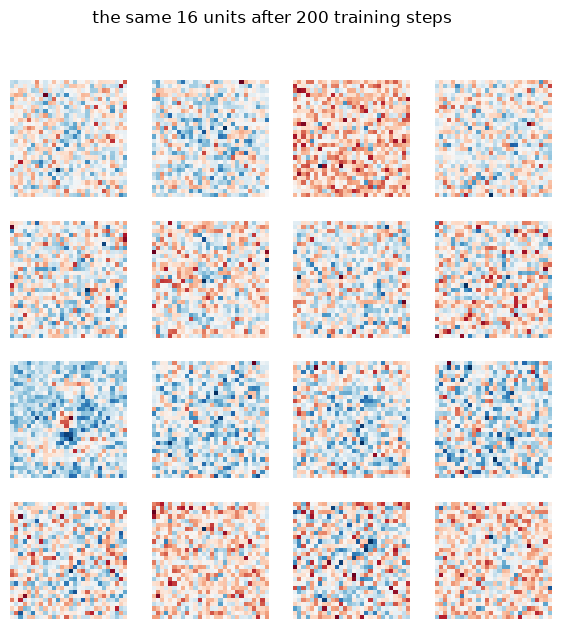

In [8]:
# figure 1: loss and accuracy over the run
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.plot(step_marks, losses, "o-", color="tab:blue")
ax1.set_xlabel("training step"); ax1.set_ylabel("loss")
ax1.grid(alpha=0.3)
ax2.plot(step_marks, train_accs, "s-", label="training images")
ax2.plot(step_marks, test_accs, "s--", label="held-out test images")
ax2.set_xlabel("training step"); ax2.set_ylabel("accuracy")
ax2.legend(); ax2.grid(alpha=0.3)
plt.show()

# figure 2: the hidden units' weights, as pictures, at the random start and after training
def unit_grid(weights, title):
    fig, axs = plt.subplots(4, 4, figsize=(7, 7))
    rows = weights.detach().T.numpy()
    for i, ax in enumerate(axs.flat):
        row = rows[i]
        row = (row - row.min()) / (row.max() - row.min() + 1e-9)   # scale for display
        ax.imshow(row.reshape(28, 28), cmap="RdBu_r")
        ax.axis("off")
    fig.suptitle(title, fontsize=12)
    plt.show()

unit_grid(W1_start, "the 16 hidden units at the random start")
unit_grid(W1, "the same 16 units after 200 training steps")

The units went from noise to structure, though few of them became a clean picture of a 3 or a 7. That is normal: nothing forces a single unit to hold the whole job. The discrimination is spread across the units, and the network reads it back out with $W_2$.

One honest way to see the whole decision at once is to fold the two weight layers together. The composite vector $W_1 W_2$ has one entry per pixel: roughly, how much that pixel counts toward "3" when the network makes up its mind. The figure compares that composite to what the data itself says: the average 3 minus the average 7, pixel by pixel. If the network learned the real distinction, the two pictures should match.

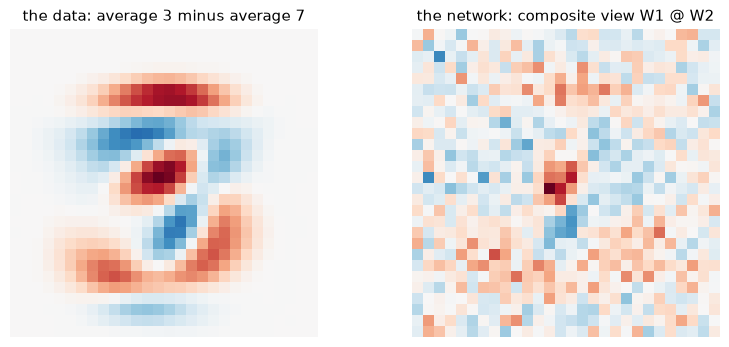

agreement between the two pictures: 0.49


In [9]:
# the data's own view: average 3 minus average 7
mean_3 = Xtr[ttr[:, 0] == 1].mean(dim=0)
mean_7 = Xtr[ttr[:, 0] == 0].mean(dim=0)
data_ghost = (mean_3 - mean_7).numpy()

# the network's view: pixels folded through both weight layers
with torch.no_grad():
    composite = (W1 @ W2).numpy().ravel()

agreement = np.corrcoef(composite, data_ghost)[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, img, title in (
    (ax1, data_ghost, "the data: average 3 minus average 7"),
    (ax2, composite, "the network: composite view W1 @ W2"),
):
    m = max(abs(img.min()), abs(img.max()))
    ax.imshow(img.reshape(28, 28), cmap="RdBu_r", vmin=-m, vmax=m)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
plt.show()
print(f"agreement between the two pictures: {agreement:.2f}")

**Generalization, modestly.** The network gets about 98% of the held-out test images right, and those images never appeared in training. That is the same claim week two made for the linear model: accuracy on images the model never saw is the evidence that it learned the 3-versus-7 distinction in general, rather than memorizing the training set. The error rate deserves an honest look too. Roughly 40 of the 2,038 test images are misclassified, and when the network is wrong it is not expressing doubt: a 7 that happens to look like a 3 to it can receive a strong 3-score. The score measures how well the image matches the learned pattern, not how sure the network is. (The score can even sit below 0 or above 1: it is a raw weighted sum, not a probability.)

**Stop and check yourself.** Pick one weight, say $W_1$[3, 7], the weight from pixel 3 to hidden unit 7. When `loss.backward()` computes `W1.grad[3, 7]`, what two things from the forward pass does it multiply together, and why was it important that the forward pass recorded them? (Answer: the chain of slopes built on the way back from the loss to unit 7, and the value that flowed through $W_1$[3, 7]'s operation during the forward pass: the pixel value itself. The backward pass only has the rules; the recorded forward values are what the rules are evaluated at. This multiplication of a backward chain by a forward value, operation by operation, is backpropagation.)

## Summary

| term | what it is | in this network |
|---|---|---|
| unit (neuron) | adds its weighted inputs plus a bias, squeezes the sum with the sigmoid | one of the 16 hidden units |
| layer | a column of units that all read the same input | input (784 pixels), hidden (16 units), output (one score) |
| weight | the strength of one connection between layers | an entry of $W_1$ or $W_2$ |
| bias | a number added to a unit's sum, belonging to that unit | an entry of $b_1$, or $b_2$ itself |
| parameter | any number the model chooses and adjusts | the 12,577 entries of $W_1, b_1, W_2, b_2$ |
| activation | the value a layer sends on to the next layer | the hidden layer's output: the 16 firing rates $h$ |
| forward pass | values computed layer by layer, each operation recorded | `h_pre`, `h`, `y_hat`, then the loss |
| backward pass (backpropagation) | the record walked in reverse, rules chained over recorded values | `loss.backward()` |
| gradient descent | move every parameter a small step against its slope, repeatedly | 200 steps with `lr = 0.1` |
| loss | one number rating the whole model | the squared error, about 0.025 when training ends |
| held-out test set | images the model never trained on | the 2,038 test images |

The shape of the week: a new representation (the layered network), the same evaluation (squared error), and an optimization made affordable. Week two's gradient descent nudged a parameter to measure its slope, two extra forward passes per parameter, which is why scanning over a grid of settings died by multiplication. Here the backward pass replaces the nudging: one walk over the record yields all 12,577 slopes.

In "A Few Useful Things to Know about Machine Learning" (2012), Domingos gives the reason the held-out images, not the training ones, are the ones that matter:

> The fundamental goal of machine learning is to generalize beyond the examples in the training set. This is because, no matter how much data we have, it is very unlikely that we will see those exact examples again at test time.

The network learned a pattern for 3s and 7s, and the test set checks whether the pattern holds for images it has not seen. That check is what makes this notebook's accuracy numbers mean something. Thursday we solve the study guide together, and Quiz 01 covers this week's vocabulary: the terms in the table above are the words to know.

---

## Further exploration

### Backpropagation, in the classic explainer

Christopher Olah, "Calculus on Computational Graphs: Backpropagation" (2015): https://colah.github.io/posts/2015-08-Backprop/ . The two figures above come from that post, and the post expands on the mathematical details.

### Pytorch's own tour

The "Neural Networks" page of the official Pytorch tutorial: https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html .